In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

#import numpy as np # linear algebra
#import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

#import os
#for dirname, _, filenames in os.walk('/kaggle/input'):
    #for filename in filenames:
        #print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

#import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [46]:
import os
import shutil

# Create the Kaggle config directory
os.makedirs("/root/.kaggle", exist_ok=True)

# Copy your API token to the expected location
shutil.copy(
    "/kaggle/input/datasets/palakmahajan14/kaggle-api-token/kaggle.json",
    "/root/.kaggle/kaggle.json"
)

# Set secure permissions
os.chmod("/root/.kaggle/kaggle.json", 0o600)

print("Kaggle API configured successfully!")

Kaggle API configured successfully!


In [47]:
!pip install -q kaggle

In [49]:
!pip install -q librosa==0.10.2
!pip install -q audiomentations
!pip install -q transformers
!pip install -q soundfile
!pip install -q spafe
!pip install -q praat-parselmouth
!pip install -q faiss-cpu
!pip install -q torchmetrics

In [50]:
import os
import random
import warnings
import numpy as np
import pandas as pd

import librosa
import soundfile as sf

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import GroupShuffleSplit

from transformers import AutoFeatureExtractor
from transformers import Wav2Vec2Model

warnings.filterwarnings("ignore")

# -------------------------
# Reproducibility
# -------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------
# Audio Settings
# -------------------------

SR = 16000
DURATION = 4
MAX_LEN = SR * DURATION

BATCH_SIZE = 16
NUM_WORKERS = 2

# -------------------------
# Dataset
# -------------------------

ROOT = "/kaggle/input/asvspoof-2019/LA"

TRAIN_AUDIO = os.path.join(ROOT,"ASVspoof2019_LA_train/flac")
DEV_AUDIO   = os.path.join(ROOT,"ASVspoof2019_LA_dev/flac")
EVAL_AUDIO  = os.path.join(ROOT,"ASVspoof2019_LA_eval/flac")

PROTOCOL_DIR = os.path.join(ROOT,"ASVspoof2019_LA_cm_protocols")

print(DEVICE)

cuda


In [5]:
import os

ROOT = "/kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/LA/LA"

print(os.path.exists(ROOT))
print(os.listdir(ROOT))

True
['ASVspoof2019_LA_dev', 'ASVspoof2019_LA_train', 'ASVspoof2019_LA_cm_protocols', 'ASVspoof2019_LA_eval', 'ASVspoof2019_LA_asv_protocols', 'README.LA.txt', 'ASVspoof2019_LA_asv_scores']


In [6]:
import os

PROTOCOL_DIR = "/kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/LA/LA/ASVspoof2019_LA_cm_protocols"

print(os.listdir(PROTOCOL_DIR))

['ASVspoof2019.LA.cm.eval.trl.txt', 'ASVspoof2019.LA.cm.train.trn.txt', 'ASVspoof2019.LA.cm.dev.trl.txt']


In [7]:
# ============================================================
# Cell 3 : Read Official ASVspoof 2019 Protocol Files
# ============================================================

import os
import pandas as pd

ROOT = "/kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/LA/LA"

TRAIN_AUDIO = os.path.join(ROOT, "ASVspoof2019_LA_train", "flac")
DEV_AUDIO   = os.path.join(ROOT, "ASVspoof2019_LA_dev", "flac")
EVAL_AUDIO  = os.path.join(ROOT, "ASVspoof2019_LA_eval", "flac")

PROTOCOL_DIR = os.path.join(ROOT, "ASVspoof2019_LA_cm_protocols")


# ---------------------------------------------------------
# Read Protocol File
# ---------------------------------------------------------

def read_protocol(protocol_path, audio_folder):

    rows = []

    with open(protocol_path, "r") as f:

        for line in f:

            parts = line.strip().split()

            rows.append({

                "speaker": parts[0],
                "file": parts[1],
                "attack": parts[3],
                "label": 1 if parts[4] == "bonafide" else 0,
                "path": os.path.join(audio_folder, parts[1] + ".flac")

            })

    return pd.DataFrame(rows)


# ---------------------------------------------------------
# Read Official Splits
# ---------------------------------------------------------

train_df = read_protocol(
    os.path.join(PROTOCOL_DIR, "ASVspoof2019.LA.cm.train.trn.txt"),
    TRAIN_AUDIO
)

dev_df = read_protocol(
    os.path.join(PROTOCOL_DIR, "ASVspoof2019.LA.cm.dev.trl.txt"),
    DEV_AUDIO
)

eval_df = read_protocol(
    os.path.join(PROTOCOL_DIR, "ASVspoof2019.LA.cm.eval.trl.txt"),
    EVAL_AUDIO
)


print("=" * 60)
print("Official ASVspoof 2019 Dataset")
print("=" * 60)

print(f"Train Samples : {len(train_df)}")
print(f"Dev Samples   : {len(dev_df)}")
print(f"Eval Samples  : {len(eval_df)}")

print()

print("Train Speakers :", train_df.speaker.nunique())
print("Dev Speakers   :", dev_df.speaker.nunique())
print("Eval Speakers  :", eval_df.speaker.nunique())

print()

print("Train Labels")
print(train_df.label.value_counts())

print()

print("Dev Labels")
print(dev_df.label.value_counts())

print()

print("Eval Labels")
print(eval_df.label.value_counts())

Official ASVspoof 2019 Dataset
Train Samples : 25380
Dev Samples   : 24844
Eval Samples  : 71237

Train Speakers : 20
Dev Speakers   : 20
Eval Speakers  : 67

Train Labels
label
0    22800
1     2580
Name: count, dtype: int64

Dev Labels
label
0    22296
1     2548
Name: count, dtype: int64

Eval Labels
label
0    63882
1     7355
Name: count, dtype: int64


In [10]:
from audiomentations import Compose
from audiomentations import AddGaussianNoise
from audiomentations import PitchShift
from audiomentations import TimeStretch
from audiomentations import Gain
from audiomentations import Shift
from audiomentations import AirAbsorption

# ==========================================================
# Train Augmentation
# ==========================================================

train_augment = Compose([

    AddGaussianNoise(
        min_amplitude=0.001,
        max_amplitude=0.015,
        p=0.40
    ),

    PitchShift(
        min_semitones=-2,
        max_semitones=2,
        p=0.30
    ),

    TimeStretch(
        min_rate=0.90,
        max_rate=1.10,
        p=0.30
    ),

    Gain(
        min_gain_db=-6,
        max_gain_db=6,
        p=0.30
    ),

    Shift(
        min_shift=-0.10,
        max_shift=0.10,
        p=0.25
    ),

    AirAbsorption(
        p=0.20
    )

])

# ==========================================================
# Validation/Test
# ==========================================================

val_augment = None
test_augment = None

print("✓ Augmentation Pipeline Ready")

✓ Augmentation Pipeline Ready


In [11]:
import librosa
import numpy as np
import torch
from torch.utils.data import Dataset

SR = 16000
DURATION = 4
MAX_LEN = SR * DURATION


class ASVSpoofDataset(Dataset):

    def __init__(self, dataframe, augment=None):

        self.df = dataframe
        self.augment = augment

    def __len__(self):

        return len(self.df)

    def load_audio(self, path):

        audio, sr = librosa.load(
            path,
            sr=SR
        )

        # -----------------------
        # Pad / Crop
        # -----------------------

        if len(audio) < MAX_LEN:

            pad = MAX_LEN - len(audio)

            audio = np.pad(
                audio,
                (0, pad)
            )

        elif len(audio) > MAX_LEN:

            start = np.random.randint(
                0,
                len(audio) - MAX_LEN + 1
            )

            audio = audio[start:start + MAX_LEN]

        return audio

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        audio = self.load_audio(row.path)

        if self.augment is not None:

            audio = self.augment(
                samples=audio,
                sample_rate=SR
            )

        return {

            "audio": torch.FloatTensor(audio),

            "label": torch.tensor(
                row.label,
                dtype=torch.long
            ),

            "speaker": row.speaker,

            "attack": row.attack,

            "file": row.file

        }

In [12]:
# ============================================================
# Cell 5 : Dataset Class
# ============================================================

import os
import random
import librosa
import numpy as np
import torch
from torch.utils.data import Dataset

# -----------------------------
# Audio Parameters
# -----------------------------

SR = 16000
DURATION = 4          # seconds
MAX_LEN = SR * DURATION


class ASVSpoofDataset(Dataset):

    def __init__(self, dataframe, augment=None):

        self.df = dataframe.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def load_audio(self, path):

        if not os.path.exists(path):
            raise FileNotFoundError(f"Audio file not found:\n{path}")

        audio, _ = librosa.load(
            path,
            sr=SR,
            mono=True
        )

        # -------------------------
        # Crop or Pad
        # -------------------------

        if len(audio) > MAX_LEN:

            start = random.randint(
                0,
                len(audio) - MAX_LEN
            )

            audio = audio[start:start + MAX_LEN]

        elif len(audio) < MAX_LEN:

            pad = MAX_LEN - len(audio)

            audio = np.pad(
                audio,
                (0, pad),
                mode="constant"
            )

        return audio.astype(np.float32)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        path = row["path"]

        audio = self.load_audio(path)

        # -------------------------
        # Augmentation (Train Only)
        # -------------------------

        if self.augment is not None:

            audio = self.augment(
                samples=audio,
                sample_rate=SR
            )

            audio = np.asarray(audio, dtype=np.float32)

        sample = {

            "audio": torch.from_numpy(audio),

            "label": torch.tensor(
                int(row["label"]),
                dtype=torch.long
            ),

            "speaker": str(row["speaker"]),

            "attack": str(row["attack"]),

            "file": str(row["file"])

        }

        return sample


print("✓ Dataset class created successfully.")

✓ Dataset class created successfully.


In [13]:
sample = ASVSpoofDataset(train_df)

print(len(sample))

x = sample[0]

print(x["audio"].shape)
print(x["label"])
print(x["speaker"])
print(x["attack"])
print(x["file"])

25380
torch.Size([64000])
tensor(1)
LA_0079
-
LA_T_1138215


In [16]:
# ============================================================
# Cell 6 : Dataset Objects and DataLoaders (Official Splits)
# ============================================================

from torch.utils.data import DataLoader

BATCH_SIZE = 16

# ------------------------------------------------------------
# Dataset Objects
# ------------------------------------------------------------

train_dataset = ASVSpoofDataset(
    dataframe=train_df,
    augment=train_augment
)

dev_dataset = ASVSpoofDataset(
    dataframe=dev_df,
    augment=None
)

eval_dataset = ASVSpoofDataset(
    dataframe=eval_df,
    augment=None
)

print("Datasets Created")
print("-" * 50)
print(f"Train : {len(train_dataset)}")
print(f"Dev   : {len(dev_dataset)}")
print(f"Eval  : {len(eval_dataset)}")


# ------------------------------------------------------------
# DataLoaders
# ------------------------------------------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True
)

dev_loader = DataLoader(
    dev_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

eval_loader = DataLoader(
    eval_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("\nDataLoaders Ready")

Datasets Created
--------------------------------------------------
Train : 25380
Dev   : 24844
Eval  : 71237

DataLoaders Ready


In [17]:
batch = next(iter(train_loader))

print(batch["audio"].shape)
print(batch["label"].shape)
print(batch["speaker"][:3])
print(batch["file"][:3])

torch.Size([16, 64000])
torch.Size([16])
['LA_0082', 'LA_0087', 'LA_0079']
['LA_T_5061576', 'LA_T_4460204', 'LA_T_4114067']


In [18]:
# ============================================================
# Cell 7 : MFCC Feature Extraction
# ============================================================

import librosa
import numpy as np

N_MFCC = 80

def extract_mfcc(audio):

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=SR,
        n_mfcc=N_MFCC,
        n_fft=512,
        hop_length=160,
        win_length=400
    )

    # Delta
    delta = librosa.feature.delta(mfcc)

    # Delta-Delta
    delta2 = librosa.feature.delta(
        mfcc,
        order=2
    )

    # Mean Pool
    mfcc_mean = np.mean(mfcc, axis=1)

    delta_mean = np.mean(delta, axis=1)

    delta2_mean = np.mean(delta2, axis=1)

    feature = np.concatenate([

        mfcc_mean,

        delta_mean,

        delta2_mean

    ])

    return feature.astype(np.float32)


# ---------------------------------------------------
# Test
# ---------------------------------------------------

sample = train_dataset[0]

mfcc = extract_mfcc(sample["audio"].numpy())

print(mfcc.shape)

(240,)


In [19]:
# ============================================================
# Cell 8 : CQCC Feature Extraction
# ============================================================

import librosa
import numpy as np
from scipy.fftpack import dct

N_CQCC = 80


def extract_cqcc(audio):

    # -------------------------------------------------
    # Constant-Q Transform
    # -------------------------------------------------

    cqt = np.abs(
        librosa.cqt(
            y=audio,
            sr=SR,
            hop_length=160,
            bins_per_octave=12,
            n_bins=84
        )
    )

    # -------------------------------------------------
    # Log Power
    # -------------------------------------------------

    log_cqt = np.log(cqt + 1e-8)

    # -------------------------------------------------
    # Cepstral Coefficients
    # -------------------------------------------------

    cqcc = dct(
        log_cqt,
        axis=0,
        norm="ortho"
    )

    cqcc = cqcc[:N_CQCC]

    # -------------------------------------------------
    # Delta
    # -------------------------------------------------

    delta = librosa.feature.delta(cqcc)

    # -------------------------------------------------
    # Delta-Delta
    # -------------------------------------------------

    delta2 = librosa.feature.delta(
        cqcc,
        order=2
    )

    # -------------------------------------------------
    # Mean Pooling
    # -------------------------------------------------

    cqcc_mean = np.mean(cqcc, axis=1)

    delta_mean = np.mean(delta, axis=1)

    delta2_mean = np.mean(delta2, axis=1)

    feature = np.concatenate([

        cqcc_mean,

        delta_mean,

        delta2_mean

    ])

    return feature.astype(np.float32)


# ============================================================
# Test
# ============================================================

sample = train_dataset[0]

cqcc = extract_cqcc(
    sample["audio"].numpy()
)

print("CQCC Shape :", cqcc.shape)

CQCC Shape : (240,)


In [22]:
# ============================================================
# Cell 9 : LFCC Feature Extraction
# ============================================================

import numpy as np
import librosa
from spafe.features.lfcc import lfcc as spafe_lfcc

N_LFCC = 80

def extract_lfcc(audio):

    # LFCC extraction
    lfcc_feat = spafe_lfcc(
        sig=audio,
        fs=SR,
        num_ceps=N_LFCC,
        nfilts=80,
        nfft=512,
        low_freq=0,
        high_freq=SR // 2
    )

    # (frames, coeffs) -> (coeffs, frames)
    lfcc_feat = lfcc_feat.T

    delta = librosa.feature.delta(lfcc_feat)

    delta2 = librosa.feature.delta(
        lfcc_feat,
        order=2
    )

    feature = np.concatenate([

        np.mean(lfcc_feat, axis=1),

        np.mean(delta, axis=1),

        np.mean(delta2, axis=1)

    ])

    return feature.astype(np.float32)

In [23]:
# ============================================================
# Cell 10 : Spectral Feature Extraction
# ============================================================

import numpy as np
import librosa

def extract_spectral(audio):

    # --------------------------------------------
    # Spectral Centroid
    # --------------------------------------------
    centroid = librosa.feature.spectral_centroid(
        y=audio,
        sr=SR
    )

    # --------------------------------------------
    # Spectral Bandwidth
    # --------------------------------------------
    bandwidth = librosa.feature.spectral_bandwidth(
        y=audio,
        sr=SR
    )

    # --------------------------------------------
    # Spectral Roll-off
    # --------------------------------------------
    rolloff = librosa.feature.spectral_rolloff(
        y=audio,
        sr=SR
    )

    # --------------------------------------------
    # Spectral Flatness
    # --------------------------------------------
    flatness = librosa.feature.spectral_flatness(
        y=audio
    )

    # --------------------------------------------
    # Zero Crossing Rate
    # --------------------------------------------
    zcr = librosa.feature.zero_crossing_rate(
        audio
    )

    # --------------------------------------------
    # RMS Energy
    # --------------------------------------------
    rms = librosa.feature.rms(
        y=audio
    )

    # --------------------------------------------
    # Spectral Contrast
    # --------------------------------------------
    contrast = librosa.feature.spectral_contrast(
        y=audio,
        sr=SR
    )

    # =========================================================
    # Mean Pooling
    # =========================================================

    feature = np.concatenate([

        np.mean(centroid, axis=1),

        np.mean(bandwidth, axis=1),

        np.mean(rolloff, axis=1),

        np.mean(flatness, axis=1),

        np.mean(zcr, axis=1),

        np.mean(rms, axis=1),

        np.mean(contrast, axis=1)

    ])

    return feature.astype(np.float32)


# ============================================================
# Test
# ============================================================

sample = train_dataset[0]

spectral = extract_spectral(
    sample["audio"].numpy()
)

print("Spectral Feature Shape :", spectral.shape)

print(spectral)

Spectral Feature Shape : (13,)
[1.3845073e+03 1.2042990e+03 2.5698164e+03 1.4775303e-01 1.1449808e-01
 8.9213431e-02 3.4446960e+01 1.6689684e+01 1.8691669e+01 1.7785154e+01
 1.8991983e+01 2.2204000e+01 1.6774061e+01]


In [24]:
# ============================================================
# Cell 11 : Prosodic Feature Extraction
# ============================================================

import numpy as np
import librosa

def extract_prosody(audio):

    # -------------------------------------------------------
    # Pitch (Fundamental Frequency)
    # -------------------------------------------------------

    f0, voiced_flag, voiced_probs = librosa.pyin(
        audio,
        fmin=librosa.note_to_hz('C2'),
        fmax=librosa.note_to_hz('C7'),
        sr=SR
    )

    # Remove NaNs from unvoiced regions
    pitch = f0[~np.isnan(f0)]

    if len(pitch) == 0:
        pitch_mean = 0
        pitch_std = 0
    else:
        pitch_mean = np.mean(pitch)
        pitch_std = np.std(pitch)

    # -------------------------------------------------------
    # RMS Energy
    # -------------------------------------------------------

    energy = librosa.feature.rms(y=audio)[0]

    energy_mean = np.mean(energy)
    energy_std = np.std(energy)

    # -------------------------------------------------------
    # Voiced Ratio
    # -------------------------------------------------------

    voiced_ratio = np.mean(voiced_flag.astype(np.float32))

    # -------------------------------------------------------
    # Prosody Vector
    # -------------------------------------------------------

    feature = np.array([

        pitch_mean,
        pitch_std,

        energy_mean,
        energy_std,

        voiced_ratio

    ], dtype=np.float32)

    return feature


# ============================================================
# Test
# ============================================================

sample = train_dataset[0]

prosody = extract_prosody(
    sample["audio"].numpy()
)

print("Prosody Shape :", prosody.shape)
print(prosody)

Prosody Shape : (5,)
[2.1852448e+02 9.6380409e+01 5.2250840e-02 7.2480172e-02 4.9206349e-01]


In [25]:
# ============================================================
# Cell 12 : Physics-Guided Features
# ============================================================

import numpy as np
import parselmouth


def extract_physics(audio):

    # -------------------------------------------------------
    # Convert NumPy array to Praat Sound object
    # -------------------------------------------------------

    sound = parselmouth.Sound(audio, sampling_frequency=SR)

    # -------------------------------------------------------
    # Pitch
    # -------------------------------------------------------

    pitch = sound.to_pitch()

    pitch_values = pitch.selected_array["frequency"]
    pitch_values = pitch_values[pitch_values > 0]

    if len(pitch_values) == 0:
        mean_pitch = 0.0
    else:
        mean_pitch = np.mean(pitch_values)

    # -------------------------------------------------------
    # Point Process (required for jitter & shimmer)
    # -------------------------------------------------------

    point_process = parselmouth.praat.call(
        sound,
        "To PointProcess (periodic, cc)",
        75,
        500
    )

    # -------------------------------------------------------
    # Jitter
    # -------------------------------------------------------

    jitter = parselmouth.praat.call(
        point_process,
        "Get jitter (local)",
        0,
        0,
        0.0001,
        0.02,
        1.3
    )

    # -------------------------------------------------------
    # Shimmer
    # -------------------------------------------------------

    shimmer = parselmouth.praat.call(
        [sound, point_process],
        "Get shimmer (local)",
        0,
        0,
        0.0001,
        0.02,
        1.3,
        1.6
    )

    # -------------------------------------------------------
    # Harmonic-to-Noise Ratio (HNR)
    # -------------------------------------------------------

    harmonicity = sound.to_harmonicity()

    hnr = parselmouth.praat.call(
        harmonicity,
        "Get mean",
        0,
        0
    )

    # -------------------------------------------------------
    # Intensity
    # -------------------------------------------------------

    intensity = sound.to_intensity()

    mean_intensity = parselmouth.praat.call(
        intensity,
        "Get mean",
        0,
        0,
        "energy"
    )

    # -------------------------------------------------------
    # Feature Vector
    # -------------------------------------------------------

    feature = np.array([

        mean_pitch,

        jitter,

        shimmer,

        hnr,

        mean_intensity

    ], dtype=np.float32)

    feature = np.nan_to_num(feature)

    return feature


# ============================================================
# Test
# ============================================================

sample = train_dataset[0]

physics = extract_physics(
    sample["audio"].numpy()
)

print("Physics Feature Shape :", physics.shape)
print(physics)

Physics Feature Shape : (5,)
[2.6066528e+02 1.7705409e-02 8.9393698e-02 1.1995246e+01 7.3097748e+01]


In [26]:
!pip install -q transformers sentencepiece

In [27]:
# ============================================================
# Cell 13 : Load XLS-R
# ============================================================
from transformers import Wav2Vec2FeatureExtractor, Wav2Vec2Model
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_NAME = "facebook/wav2vec2-xls-r-300m"

feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(MODEL_NAME)

xlsr_model = Wav2Vec2Model.from_pretrained(MODEL_NAME).to(DEVICE)
xlsr_model.eval()

preprocessor_config.json:   0%|          | 0.00/212 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.27G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.27G [00:00<?, ?B/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-xls-r-300m
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Wav2Vec2Model(
  (feature_extractor): Wav2Vec2FeatureEncoder(
    (conv_layers): ModuleList(
      (0): Wav2Vec2LayerNormConvLayer(
        (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,))
        (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (activation): GELUActivation()
      )
      (1-4): 4 x Wav2Vec2LayerNormConvLayer(
        (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,))
        (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (activation): GELUActivation()
      )
      (5-6): 2 x Wav2Vec2LayerNormConvLayer(
        (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,))
        (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (activation): GELUActivation()
      )
    )
  )
  (feature_projection): Wav2Vec2FeatureProjection(
    (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (projection): Linear(in_features=512, out_features=1024, bias=True)
    (dropout)

In [28]:
# ============================================================
# Cell 14 : XLS-R Feature Extraction
# ============================================================

import numpy as np
import torch

@torch.no_grad()
def extract_xlsr(audio):

    inputs = feature_extractor(
        audio,
        sampling_rate=16000,
        return_tensors="pt"
    )

    input_values = inputs.input_values.to(DEVICE)

    outputs = xlsr_model(input_values)

    embedding = outputs.last_hidden_state.mean(dim=1)

    return embedding.squeeze(0).cpu().numpy().astype(np.float32)

In [29]:
sample = train_dataset[0]

emb = extract_xlsr(sample["audio"].numpy())

print(emb.shape)

(1024,)


In [30]:
# ============================================================
# Cell 15 : Test Individual Feature Extractors
# ============================================================

sample = train_dataset[0]

audio = sample["audio"].numpy()

print("Extracting features...\n")

mfcc = extract_mfcc(audio)
print("MFCC      :", mfcc.shape)

cqcc = extract_cqcc(audio)
print("CQCC      :", cqcc.shape)

lfcc = extract_lfcc(audio)
print("LFCC      :", lfcc.shape)

spectral = extract_spectral(audio)
print("Spectral  :", spectral.shape)

prosody = extract_prosody(audio)
print("Prosody   :", prosody.shape)

physics = extract_physics(audio)
print("Physics   :", physics.shape)

xlsr = extract_xlsr(audio)
print("XLS-R     :", xlsr.shape)

Extracting features...

MFCC      : (240,)
CQCC      : (240,)
LFCC      : (240,)
Spectral  : (13,)
Prosody   : (5,)
Physics   : (5,)
XLS-R     : (1024,)


In [31]:
# ============================================================
# Cell 16 : Hybrid Feature Fusion
# ============================================================

import numpy as np

def extract_all_features(audio):

    # -----------------------------
    # Handcrafted Features
    # -----------------------------

    mfcc_feature = extract_mfcc(audio)

    cqcc_feature = extract_cqcc(audio)

    lfcc_feature = extract_lfcc(audio)

    spectral_feature = extract_spectral(audio)

    prosody_feature = extract_prosody(audio)

    physics_feature = extract_physics(audio)

    # -----------------------------
    # Deep Representation
    # -----------------------------

    xlsr_feature = extract_xlsr(audio)

    # -----------------------------
    # Concatenate Everything
    # -----------------------------

    hybrid_feature = np.concatenate([

        mfcc_feature,          # 240

        cqcc_feature,          # 240

        lfcc_feature,          # 240

        spectral_feature,      # 13

        prosody_feature,       # 5

        physics_feature,       # 5

        xlsr_feature           # 1024

    ], axis=0)

    return hybrid_feature.astype(np.float32)


# ============================================================
# Test Hybrid Feature Vector
# ============================================================

sample = train_dataset[0]

audio = sample["audio"].numpy()

hybrid_feature = extract_all_features(audio)

print("=" * 50)
print("Hybrid Feature Vector")
print("=" * 50)

print("Shape :", hybrid_feature.shape)
print("Datatype :", hybrid_feature.dtype)

print("\nFirst 20 Values:\n")
print(hybrid_feature[:20])

Hybrid Feature Vector
Shape : (1767,)
Datatype : float32

First 20 Values:

[-509.14838     38.293636    -9.965133    11.483927   -19.795628
   -1.6183306   -5.475866    -4.4481497   -1.0471784  -10.988122
   -5.4605002   -1.902042    -2.3308167   -8.502194    -6.7068205
   -2.9510117   -3.0799499    1.7339007   -0.5193987   -2.3840277]


In [32]:
from transformers import Wav2Vec2FeatureExtractor, Wav2Vec2Model
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_NAME = "facebook/wav2vec2-xls-r-300m"

print("Loading XLS-R model...")

feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(
    MODEL_NAME
)

xlsr_model = Wav2Vec2Model.from_pretrained(
    MODEL_NAME
)

xlsr_model = xlsr_model.to(DEVICE)
xlsr_model.eval()

print(type(xlsr_model))

Loading XLS-R model...


Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-xls-r-300m
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


<class 'transformers.models.wav2vec2.modeling_wav2vec2.Wav2Vec2Model'>


In [33]:
print(type(feature_extractor))
print(type(xlsr_model))

<class 'transformers.models.wav2vec2.feature_extraction_wav2vec2.Wav2Vec2FeatureExtractor'>
<class 'transformers.models.wav2vec2.modeling_wav2vec2.Wav2Vec2Model'>


In [34]:
# ============================================================
# Cell 17A : Parallel Handcrafted Feature Extraction
# ============================================================

from concurrent.futures import ThreadPoolExecutor
import numpy as np

def extract_handcrafted(audio):

    mfcc = extract_mfcc(audio)

    cqcc = extract_cqcc(audio)

    lfcc = extract_lfcc(audio)

    spectral = extract_spectral(audio)

    prosody = extract_prosody(audio)

    physics = extract_physics(audio)

    return np.concatenate([
        mfcc,
        cqcc,
        lfcc,
        spectral,
        prosody,
        physics
    ]).astype(np.float32)


def extract_handcrafted_batch(audio_batch):

    with ThreadPoolExecutor(max_workers=8) as executor:

        features = list(
            executor.map(
                extract_handcrafted,
                audio_batch
            )
        )

    return features

In [35]:
@torch.no_grad()
def extract_xlsr_batch(audio_batch):

    inputs = feature_extractor(

        audio_batch,

        sampling_rate=16000,

        padding=True,

        return_tensors="pt"

    )

    input_values = inputs.input_values.to(DEVICE)

    outputs = xlsr_model(input_values)

    embeddings = outputs.last_hidden_state.mean(dim=1)

    return embeddings.cpu().numpy()

In [36]:
# ============================================================
# Checkpoint persistence setup (Kaggle Dataset push)
# ============================================================

import os
import json
import shutil

# ============================================================
# Kaggle Dataset (where checkpoints will be stored)
# ============================================================

DATASET_SLUG = "palakmahajan14/hybrid-features-checkpoints"

CKPT_UPLOAD_DIR = "/kaggle/working/ckpt_upload"
os.makedirs(CKPT_UPLOAD_DIR, exist_ok=True)

# Create dataset metadata
metadata = {
    "title": "hybrid-features-checkpoints",
    "id": DATASET_SLUG
}

with open(
    os.path.join(CKPT_UPLOAD_DIR, "dataset-metadata.json"),
    "w"
) as f:
    json.dump(metadata, f, indent=2)


def push_checkpoint_to_dataset(zip_path, message):
    """
    Upload the latest checkpoint ZIP to the Kaggle Dataset.
    If anything goes wrong, training continues.
    """

    from kaggle.api.kaggle_api_extended import KaggleApi

    try:
        # -------------------------------------------------------
        # Remove any previous checkpoint ZIPs
        # -------------------------------------------------------
        for file in os.listdir(CKPT_UPLOAD_DIR):
            if file.endswith(".zip"):
                os.remove(os.path.join(CKPT_UPLOAD_DIR, file))

        # -------------------------------------------------------
        # Copy newest checkpoint
        # -------------------------------------------------------
        dst = os.path.join(
            CKPT_UPLOAD_DIR,
            os.path.basename(zip_path)
        )

        shutil.copy2(zip_path, dst)

        print("\n" + "=" * 60)
        print("Uploading checkpoint...")
        print(f"Dataset : {DATASET_SLUG}")
        print(f"File    : {os.path.basename(zip_path)}")
        print(f"Message : {message}")
        print("=" * 60)

        api = KaggleApi()
        api.authenticate()

        # -------------------------------------------------------
        # Create a new dataset version
        # -------------------------------------------------------
        api.dataset_create_version(
            folder=CKPT_UPLOAD_DIR,
            version_notes=message,
            delete_old_versions=False,
            quiet=False,
        )

        print("\n✅ Checkpoint uploaded successfully!")

        # -------------------------------------------------------
        # Verify uploaded files
        # -------------------------------------------------------
        files = api.dataset_list_files(DATASET_SLUG)

        print("\nFiles currently in dataset:")

        for f in files.files:
            print(" •", f.name)

        print("=" * 60)

    except Exception as e:

        print("\n❌ Upload failed")
        print(e)
        print("Training will continue without interruption.")

In [ ]:
import os
import shutil
from tqdm.auto import tqdm

SRC = "/kaggle/input/datasets/palakmahajan14/hybrid-features-checkpoints"
DST = "/kaggle/working/hybrid_features/dev"

os.makedirs(DST, exist_ok=True)

# Only copy DEV checkpoint files
files = [f for f in os.listdir(SRC) if f.startswith("LA_D_") and f.endswith(".pt")]

print(f"Copying {len(files)} dev checkpoint files...")

for f in tqdm(files):
    shutil.copy2(
        os.path.join(SRC, f),
        os.path.join(DST, f)
    )

print("✅ Dev restore complete!")
print(f"Files restored: {len(os.listdir(DST))}")

In [37]:
import os
import shutil
from tqdm.auto import tqdm

SRC = "/kaggle/input/datasets/palakmahajan14/hybrid-features-checkpoints"
DST = "/kaggle/working/hybrid_features/eval"

os.makedirs(DST, exist_ok=True)

# Only copy EVAL checkpoint files
files = [f for f in os.listdir(SRC) if f.startswith("LA_E_") and f.endswith(".pt")]

print(f"Copying {len(files)} eval checkpoint files...")

for f in tqdm(files):
    shutil.copy2(
        os.path.join(SRC, f),
        os.path.join(DST, f)
    )

print("✅ Eval restore complete!")
print(f"Files restored: {len(os.listdir(DST))}")

Copying 64540 eval checkpoint files...


  0%|          | 0/64540 [00:00<?, ?it/s]

✅ Eval restore complete!
Files restored: 64540


In [44]:
import os
import gc
import shutil
import numpy as np
import torch
from tqdm.auto import tqdm

# ============================================================
# Configuration
# ============================================================

SAVE_DIR = "/kaggle/working/hybrid_features"
os.makedirs(SAVE_DIR, exist_ok=True)

BATCH_SIZE = 64
PRINT_EVERY = 100
CHECKPOINT_EVERY = 2500

xlsr_model.eval()


def create_checkpoint(split, save_dir):

    zip_name = os.path.join(
        "/kaggle/working",
        f"hybrid_features_{split}"
    )

    shutil.make_archive(
        zip_name,
        "zip",
        save_dir
    )

    print(f"\nCheckpoint saved -> {zip_name}.zip")

    # Push out of the ephemeral session immediately so a kernel
    # restart/disconnect can't wipe out extraction progress.
    push_checkpoint_to_dataset(f"{zip_name}.zip", f"checkpoint: {split}")


def process_split(dataset, split):

    save_dir = os.path.join(SAVE_DIR, split)
    os.makedirs(save_dir, exist_ok=True)

    # -------------------------------------------------------
    # Count existing files
    # -------------------------------------------------------

    existing = len([
        f for f in os.listdir(save_dir)
        if f.endswith(".pt")
    ])

    print("=" * 60)
    print(f"{split.upper()} SPLIT")
    print("=" * 60)
    print(f"Dataset Size     : {len(dataset)}")
    print(f"Already Extracted: {existing}")
    print(f"Remaining        : {len(dataset) - existing}")
    print("=" * 60)

    processed = 0
    skipped = 0

    pbar = tqdm(total=len(dataset), desc=split)

    for batch_idx, start in enumerate(range(0, len(dataset), BATCH_SIZE)):

        end = min(start + BATCH_SIZE, len(dataset))

        samples = []
        audio_batch = []

        # -------------------------------------------------------
        # Load only files that don't already exist
        # -------------------------------------------------------

        for i in range(start, end):

            try:
                sample = dataset[i]

            except Exception as e:

                print(f"Error loading sample {i}: {e}")
                pbar.update(1)
                continue

            save_path = os.path.join(
                save_dir,
                sample["file"] + ".pt"
            )

            if os.path.exists(save_path):

                skipped += 1
                pbar.update(1)
                continue

            samples.append(sample)
            audio_batch.append(sample["audio"].numpy())

        if len(samples) == 0:
            continue

        # -------------------------------------------------------
        # Feature Extraction
        # -------------------------------------------------------

        handcrafted_batch = extract_handcrafted_batch(audio_batch)

        with torch.inference_mode():

            xlsr_batch = extract_xlsr_batch(audio_batch)

        # -------------------------------------------------------
        # Save Features
        # -------------------------------------------------------

        for sample, handcrafted, xlsr in zip(
            samples,
            handcrafted_batch,
            xlsr_batch
        ):

            feature = np.concatenate(
                [handcrafted, xlsr]
            ).astype(np.float32)

            torch.save(
                {
                    "feature": torch.from_numpy(feature),
                    "label": int(sample["label"]),
                    "speaker": sample["speaker"],
                    "attack": sample["attack"],
                    "file": sample["file"]
                },
                os.path.join(
                    save_dir,
                    sample["file"] + ".pt"
                )
            )

            processed += 1

            # ---------------------------------------------
            # Checkpoint every N files
            # ---------------------------------------------

            if processed % CHECKPOINT_EVERY == 0:

                create_checkpoint(split, save_dir)

        pbar.update(len(samples))

        if (batch_idx + 1) % PRINT_EVERY == 0:

            print(
                f"[{split}] "
                f"Processed={processed} "
                f"Skipped={skipped}"
            )

        # -------------------------------------------------------
        # Memory Cleanup
        # -------------------------------------------------------

        del samples
        del audio_batch
        del handcrafted_batch
        del xlsr_batch

        gc.collect()

        if torch.cuda.is_available():

            torch.cuda.empty_cache()

    pbar.close()

    # -------------------------------------------------------
    # Final ZIP
    # -------------------------------------------------------

    create_checkpoint(split, save_dir)

    print("\n" + "=" * 60)
    print(f"{split.upper()} COMPLETED")
    print(f"New Features : {processed}")
    print(f"Skipped      : {skipped}")
    print("=" * 60)

In [79]:
process_split(train_dataset, "train")

TRAIN SPLIT
Dataset Size     : 25380
Already Extracted: 10000
Remaining        : 15380


train:   0%|          | 0/25380 [00:00<?, ?it/s]

[train] Processed=2800 Skipped=10000

Checkpoint saved -> /kaggle/working/hybrid_features_train.zip

Uploading checkpoint...
Dataset : palakmahajan14/hybrid-features-checkpoints
File    : hybrid_features_train.zip
Message : checkpoint: train
Starting upload for file hybrid_features_train.zip


100%|██████████| 109M/109M [00:01<00:00, 63.0MB/s] 


Upload successful: hybrid_features_train.zip (109MB)

✅ Checkpoint uploaded successfully!

Files currently in dataset:
 • LA_T_1000406.pt
 • LA_T_1000648.pt
 • LA_T_1001169.pt
 • LA_T_1001718.pt
 • LA_T_1002656.pt
 • LA_T_1003665.pt
 • LA_T_1004407.pt
 • LA_T_1004631.pt
 • LA_T_1004644.pt
 • LA_T_1005349.pt
 • LA_T_1007571.pt
 • LA_T_1007663.pt
 • LA_T_1008492.pt
 • LA_T_1010949.pt
 • LA_T_1011221.pt
 • LA_T_1012583.pt
 • LA_T_1013068.pt
 • LA_T_1013549.pt
 • LA_T_1013597.pt
 • LA_T_1014341.pt
[train] Processed=9200 Skipped=10000

Checkpoint saved -> /kaggle/working/hybrid_features_train.zip

Uploading checkpoint...
Dataset : palakmahajan14/hybrid-features-checkpoints
File    : hybrid_features_train.zip
Message : checkpoint: train
Starting upload for file hybrid_features_train.zip


...

Upload successful: hybrid_features_train.zip (145MB)

✅ Checkpoint uploaded successfully!

Files currently in dataset:
 • LA_T_1000406.pt
 • LA_T_1000648.pt
 • LA_T_1001074.pt
 • LA_T_1001169.pt
 • LA_T_1001718.pt
 • LA_T_1002656.pt
 • LA_T_1003665.pt
 • LA_T_1004407.pt
 • LA_T_1004631.pt
 • LA_T_1004644.pt
 • LA_T_1005349.pt
 • LA_T_1006715.pt
 • LA_T_1007283.pt
 • LA_T_1007408.pt
 • LA_T_1007571.pt
 • LA_T_1007615.pt
 • LA_T_1007663.pt
 • LA_T_1007914.pt
 • LA_T_1008492.pt
 • LA_T_1009193.pt

Checkpoint saved -> /kaggle/working/hybrid_features_train.zip

Uploading checkpoint...
Dataset : palakmahajan14/hybrid-features-checkpoints
File    : hybrid_features_train.zip
Message : checkpoint: train
Starting upload for file hybrid_features_train.zip


100%|██████████| 181M/181M [00:01<00:00, 99.2MB/s] 


Upload successful: hybrid_features_train.zip (181MB)

✅ Checkpoint uploaded successfully!

Files currently in dataset:
 • LA_T_1000137.pt
 • LA_T_1000406.pt
 • LA_T_1000648.pt
 • LA_T_1000824.pt
 • LA_T_1001074.pt
 • LA_T_1001114.pt
 • LA_T_1001169.pt
 • LA_T_1001718.pt
 • LA_T_1001871.pt
 • LA_T_1002656.pt
 • LA_T_1003665.pt
 • LA_T_1004407.pt
 • LA_T_1004631.pt
 • LA_T_1004644.pt
 • LA_T_1005349.pt
 • LA_T_1006715.pt
 • LA_T_1006969.pt
 • LA_T_1007217.pt
 • LA_T_1007283.pt
 • LA_T_1007408.pt

Checkpoint saved -> /kaggle/working/hybrid_features_train.zip

Uploading checkpoint...
Dataset : palakmahajan14/hybrid-features-checkpoints
File    : hybrid_features_train.zip
Message : checkpoint: train
Starting upload for file hybrid_features_train.zip


100%|██████████| 184M/184M [00:02<00:00, 90.1MB/s] 


Upload successful: hybrid_features_train.zip (184MB)

✅ Checkpoint uploaded successfully!

Files currently in dataset:
 • LA_T_1000137.pt
 • LA_T_1000406.pt
 • LA_T_1000648.pt
 • LA_T_1000824.pt
 • LA_T_1001074.pt
 • LA_T_1001114.pt
 • LA_T_1001169.pt
 • LA_T_1001718.pt
 • LA_T_1001871.pt
 • LA_T_1002656.pt
 • LA_T_1003665.pt
 • LA_T_1004407.pt
 • LA_T_1004631.pt
 • LA_T_1004644.pt
 • LA_T_1005349.pt
 • LA_T_1006715.pt
 • LA_T_1006969.pt
 • LA_T_1007217.pt
 • LA_T_1007283.pt
 • LA_T_1007408.pt

TRAIN COMPLETED
New Features : 15380
Skipped      : 10000


In [52]:
process_split(dev_dataset, "dev")

DEV SPLIT
Dataset Size     : 24844
Already Extracted: 15512
Remaining        : 9332


dev:   0%|          | 0/24844 [00:00<?, ?it/s]


Checkpoint saved -> /kaggle/working/hybrid_features_dev.zip

Uploading checkpoint...
Dataset : palakmahajan14/hybrid-features-checkpoints
File    : hybrid_features_dev.zip
Message : checkpoint: dev
Starting upload for file hybrid_features_dev.zip



  0%|          | 0.00/131M [00:00<?, ?B/s]
 10%|█         | 13.2M/131M [00:00<00:00, 136MB/s]
 21%|██        | 27.6M/131M [00:00<00:00, 139MB/s]
 31%|███▏      | 40.9M/131M [00:00<00:00, 125MB/s]
 41%|████      | 53.9M/131M [00:00<00:00, 126MB/s]
 52%|█████▏    | 67.8M/131M [00:00<00:00, 130MB/s]
 63%|██████▎   | 82.3M/131M [00:00<00:00, 137MB/s]
 73%|███████▎  | 95.5M/131M [00:00<00:00, 136MB/s]
 83%|████████▎ | 108M/131M [00:00<00:00, 131MB/s] 
100%|██████████| 131M/131M [00:01<00:00, 96.3MB/s][A


Upload successful: hybrid_features_dev.zip (131MB)

✅ Checkpoint uploaded successfully!

Files currently in dataset:
 • LA_D_1000265.pt
 • LA_D_1002200.pt
 • LA_D_1003797.pt
 • LA_D_1004406.pt
 • LA_D_1004678.pt
 • LA_D_1005471.pt
 • LA_D_1005592.pt
 • LA_D_1005971.pt
 • LA_D_1006568.pt
 • LA_D_1006800.pt
 • LA_D_1007830.pt
 • LA_D_1008673.pt
 • LA_D_1008730.pt
 • LA_D_1009810.pt
 • LA_D_1010295.pt
 • LA_D_1011190.pt
 • LA_D_1012014.pt
 • LA_D_1012999.pt
 • LA_D_1013596.pt
 • LA_D_1013783.pt
[dev] Processed=3688 Skipped=15512

Checkpoint saved -> /kaggle/working/hybrid_features_dev.zip

Uploading checkpoint...
Dataset : palakmahajan14/hybrid-features-checkpoints
File    : hybrid_features_dev.zip
Message : checkpoint: dev
Starting upload for file hybrid_features_dev.zip


...

Upload successful: hybrid_features_dev.zip (149MB)

✅ Checkpoint uploaded successfully!

Files currently in dataset:
 • LA_D_1000265.pt
 • LA_D_1002130.pt
 • LA_D_1002200.pt
 • LA_D_1002318.pt
 • LA_D_1002910.pt
 • LA_D_1003356.pt
 • LA_D_1003673.pt
 • LA_D_1003797.pt
 • LA_D_1004357.pt
 • LA_D_1004406.pt
 • LA_D_1004678.pt
 • LA_D_1005471.pt
 • LA_D_1005592.pt
 • LA_D_1005971.pt
 • LA_D_1006568.pt
 • LA_D_1006756.pt
 • LA_D_1006800.pt
 • LA_D_1007033.pt
 • LA_D_1007830.pt
 • LA_D_1008673.pt

Checkpoint saved -> /kaggle/working/hybrid_features_dev.zip

Uploading checkpoint...
Dataset : palakmahajan14/hybrid-features-checkpoints
File    : hybrid_features_dev.zip
Message : checkpoint: dev
Starting upload for file hybrid_features_dev.zip



  0%|          | 0.00/167M [00:00<?, ?B/s]
  7%|▋         | 11.6M/167M [00:00<00:01, 118MB/s]
 16%|█▌        | 26.5M/167M [00:00<00:01, 118MB/s]
 23%|██▎       | 38.7M/167M [00:00<00:01, 122MB/s]
 33%|███▎      | 55.1M/167M [00:00<00:00, 136MB/s]
 41%|████      | 68.2M/167M [00:00<00:00, 129MB/s]
 50%|████▉     | 83.1M/167M [00:00<00:00, 136MB/s]
 58%|█████▊    | 97.1M/167M [00:00<00:00, 125MB/s]
 68%|██████▊   | 113M/167M [00:00<00:00, 135MB/s] 
 75%|███████▌  | 126M/167M [00:01<00:00, 124MB/s]
 83%|████████▎ | 138M/167M [00:01<00:00, 120MB/s]
 90%|████████▉ | 150M/167M [00:01<00:00, 120MB/s]
100%|██████████| 167M/167M [00:01<00:00, 102MB/s]


Upload successful: hybrid_features_dev.zip (167MB)

✅ Checkpoint uploaded successfully!

Files currently in dataset:
 • LA_D_1000265.pt
 • LA_D_1000752.pt
 • LA_D_1002130.pt
 • LA_D_1002200.pt
 • LA_D_1002318.pt
 • LA_D_1002910.pt
 • LA_D_1003356.pt
 • LA_D_1003673.pt
 • LA_D_1003797.pt
 • LA_D_1004357.pt
 • LA_D_1004406.pt
 • LA_D_1004678.pt
 • LA_D_1005471.pt
 • LA_D_1005592.pt
 • LA_D_1005971.pt
 • LA_D_1006568.pt
 • LA_D_1006586.pt
 • LA_D_1006756.pt
 • LA_D_1006800.pt
 • LA_D_1007033.pt

Checkpoint saved -> /kaggle/working/hybrid_features_dev.zip

Uploading checkpoint...
Dataset : palakmahajan14/hybrid-features-checkpoints
File    : hybrid_features_dev.zip
Message : checkpoint: dev
Starting upload for file hybrid_features_dev.zip


100%|██████████| 180M/180M [00:01<00:00, 112MB/s] 


Upload successful: hybrid_features_dev.zip (180MB)

✅ Checkpoint uploaded successfully!

Files currently in dataset:
 • LA_D_1000265.pt
 • LA_D_1000752.pt
 • LA_D_1001095.pt
 • LA_D_1002130.pt
 • LA_D_1002200.pt
 • LA_D_1002318.pt
 • LA_D_1002626.pt
 • LA_D_1002910.pt
 • LA_D_1003356.pt
 • LA_D_1003673.pt
 • LA_D_1003797.pt
 • LA_D_1004357.pt
 • LA_D_1004406.pt
 • LA_D_1004678.pt
 • LA_D_1004774.pt
 • LA_D_1005471.pt
 • LA_D_1005592.pt
 • LA_D_1005971.pt
 • LA_D_1006568.pt
 • LA_D_1006586.pt

DEV COMPLETED
New Features : 9332
Skipped      : 15512


In [45]:
process_split(eval_dataset, "eval")  # if you're processing the full eval set

EVAL SPLIT
Dataset Size     : 71237
Already Extracted: 64540
Remaining        : 6697


eval:   0%|          | 0/71237 [00:00<?, ?it/s]


Checkpoint saved -> /kaggle/working/hybrid_features_eval.zip

Uploading checkpoint...
Dataset : palakmahajan14/hybrid-features-checkpoints
File    : hybrid_features_eval.zip
Message : checkpoint: eval
Starting upload for file hybrid_features_eval.zip



  0%|          | 0.00/487M [00:00<?, ?B/s]
  2%|▏         | 7.95M/487M [00:00<00:07, 70.5MB/s]
  5%|▌         | 26.0M/487M [00:00<00:03, 135MB/s] 
  9%|▉         | 44.3M/487M [00:00<00:02, 160MB/s]
 12%|█▏        | 59.9M/487M [00:00<00:02, 151MB/s]
 15%|█▌        | 74.6M/487M [00:00<00:03, 135MB/s]
 18%|█▊        | 88.5M/487M [00:00<00:03, 138MB/s]
 22%|██▏       | 106M/487M [00:00<00:02, 152MB/s] 
 26%|██▌       | 125M/487M [00:00<00:02, 164MB/s]
 29%|██▉       | 142M/487M [00:00<00:02, 163MB/s]
 32%|███▏      | 158M/487M [00:01<00:02, 160MB/s]
 37%|███▋      | 179M/487M [00:01<00:01, 177MB/s]
 40%|████      | 196M/487M [00:01<00:01, 177MB/s]
 44%|████▍     | 213M/487M [00:01<00:01, 177MB/s]
 47%|████▋     | 230M/487M [00:01<00:01, 175MB/s]
 51%|█████     | 247M/487M [00:01<00:01, 161MB/s]
 54%|█████▍    | 262M/487M [00:01<00:01, 153MB/s]
 57%|█████▋    | 277M/487M [00:01<00:01, 152MB/s]
 60%|█████▉    | 292M/487M [00:01<00:01, 144MB/s]
 64%|██████▎   | 310M/487M [00:02<00:01, 153MB/

Upload successful: hybrid_features_eval.zip (487MB)

✅ Checkpoint uploaded successfully!

Files currently in dataset:
 • LA_E_1000147.pt
 • LA_E_1000273.pt
 • LA_E_1000791.pt
 • LA_E_1000841.pt
 • LA_E_1000989.pt
 • LA_E_1001227.pt
 • LA_E_1001232.pt
 • LA_E_1001320.pt
 • LA_E_1001476.pt
 • LA_E_1001893.pt
 • LA_E_1001964.pt
 • LA_E_1001976.pt
 • LA_E_1002073.pt
 • LA_E_1002282.pt
 • LA_E_1002394.pt
 • LA_E_1002474.pt
 • LA_E_1002658.pt
 • LA_E_1002683.pt
 • LA_E_1002769.pt
 • LA_E_1002802.pt

Checkpoint saved -> /kaggle/working/hybrid_features_eval.zip

Uploading checkpoint...
Dataset : palakmahajan14/hybrid-features-checkpoints
File    : hybrid_features_eval.zip
Message : checkpoint: eval
Starting upload for file hybrid_features_eval.zip



  0%|          | 0.00/505M [00:00<?, ?B/s]
  2%|▏         | 8.17M/505M [00:00<00:07, 70.5MB/s]
  6%|▌         | 28.3M/505M [00:00<00:03, 146MB/s] 
  9%|▊         | 42.9M/505M [00:00<00:03, 139MB/s]
 11%|█         | 56.5M/505M [00:00<00:03, 126MB/s]
 15%|█▌        | 76.2M/505M [00:00<00:02, 151MB/s]
 18%|█▊        | 91.1M/505M [00:00<00:03, 139MB/s]
 21%|██        | 105M/505M [00:00<00:03, 135MB/s] 
 23%|██▎       | 118M/505M [00:00<00:03, 128MB/s]
 26%|██▋       | 133M/505M [00:01<00:02, 137MB/s]
 29%|██▉       | 148M/505M [00:01<00:02, 142MB/s]
 32%|███▏      | 162M/505M [00:01<00:02, 143MB/s]
 35%|███▍      | 176M/505M [00:01<00:02, 138MB/s]
 37%|███▋      | 189M/505M [00:01<00:02, 138MB/s]
 40%|████      | 203M/505M [00:01<00:02, 139MB/s]
 43%|████▎     | 219M/505M [00:01<00:02, 149MB/s]
 47%|████▋     | 237M/505M [00:01<00:01, 161MB/s]
 50%|█████     | 253M/505M [00:01<00:02, 125MB/s]
 53%|█████▎    | 266M/505M [00:02<00:01, 128MB/s]
 56%|█████▌    | 281M/505M [00:02<00:01, 131MB/

Upload successful: hybrid_features_eval.zip (505MB)

✅ Checkpoint uploaded successfully!

Files currently in dataset:
 • LA_E_1000147.pt
 • LA_E_1000273.pt
 • LA_E_1000791.pt
 • LA_E_1000841.pt
 • LA_E_1000989.pt
 • LA_E_1001227.pt
 • LA_E_1001232.pt
 • LA_E_1001320.pt
 • LA_E_1001476.pt
 • LA_E_1001893.pt
 • LA_E_1001964.pt
 • LA_E_1001976.pt
 • LA_E_1002073.pt
 • LA_E_1002282.pt
 • LA_E_1002394.pt
 • LA_E_1002474.pt
 • LA_E_1002658.pt
 • LA_E_1002683.pt
 • LA_E_1002769.pt
 • LA_E_1002802.pt
[eval] Processed=5860 Skipped=64540

Checkpoint saved -> /kaggle/working/hybrid_features_eval.zip

Uploading checkpoint...
Dataset : palakmahajan14/hybrid-features-checkpoints
File    : hybrid_features_eval.zip
Message : checkpoint: eval
Starting upload for file hybrid_features_eval.zip


100%|██████████| 517M/517M [00:05<00:00, 96.2MB/s] 


Upload successful: hybrid_features_eval.zip (517MB)

✅ Checkpoint uploaded successfully!

Files currently in dataset:
 • LA_E_1000147.pt
 • LA_E_1000273.pt
 • LA_E_1000791.pt
 • LA_E_1000841.pt
 • LA_E_1000989.pt
 • LA_E_1001227.pt
 • LA_E_1001232.pt
 • LA_E_1001320.pt
 • LA_E_1001476.pt
 • LA_E_1001893.pt
 • LA_E_1001964.pt
 • LA_E_1001976.pt
 • LA_E_1002073.pt
 • LA_E_1002282.pt
 • LA_E_1002394.pt
 • LA_E_1002474.pt
 • LA_E_1002658.pt
 • LA_E_1002683.pt
 • LA_E_1002769.pt
 • LA_E_1002802.pt

EVAL COMPLETED
New Features : 6697
Skipped      : 64540


In [2]:
import os
print(os.listdir("/kaggle/input"))

['datasets']


In [3]:
import os
print(os.listdir("/kaggle/working"))
if os.path.exists("/kaggle/working/hybrid_features"):
    for split in ["train", "dev", "eval"]:
        p = f"/kaggle/working/hybrid_features/{split}"
        if os.path.exists(p):
            print(split, "->", len(os.listdir(p)), "files")
        else:
            print(split, "-> folder not found")

['.virtual_documents']


In [5]:
import os
print(os.listdir("/kaggle/input"))
for d in os.listdir("/kaggle/input"):
    full = os.path.join("/kaggle/input", d)
    if os.path.isdir(full):
        print(d, "->", os.listdir(full))

['datasets']
datasets -> ['awsaf49', 'palakmahajan14']


In [15]:
import os
print(os.listdir("/kaggle/input/datasets/palakmahajan14"))

['hybrid-features-checkpoints', 'kaggle-api-token']


In [16]:
CKPT_ROOT = "/kaggle/input/datasets/palakmahajan14/hybrid-features-checkpoints"  # adjust if the name differs
print(os.listdir(CKPT_ROOT))

['hybrid_features_train', 'hybrid_features_dev', 'hybrid_features_eval']


In [17]:
BASE = "/kaggle/input/datasets/palakmahajan14/hybrid-features-checkpoints"
print(os.listdir(BASE))

['hybrid_features_train', 'hybrid_features_dev', 'hybrid_features_eval']


In [18]:
for split in ["hybrid_features_train", "hybrid_features_dev", "hybrid_features_eval"]:
    p = os.path.join(BASE, split)
    contents = os.listdir(p)
    print(split, "->", len(contents), "items, sample:", contents[:3])

hybrid_features_train -> 25000 items, sample: ['LA_T_6122359.pt', 'LA_T_9318376.pt', 'LA_T_9846415.pt']
hybrid_features_dev -> 24844 items, sample: ['LA_D_7382673.pt', 'LA_D_6984478.pt', 'LA_D_8872966.pt']
hybrid_features_eval -> 71237 items, sample: ['LA_E_7102298.pt', 'LA_E_5464999.pt', 'LA_E_5886907.pt']


In [20]:
import os

BASE = "/kaggle/input/datasets/palakmahajan14/hybrid-features-checkpoints"

def find_pt_dir(root):
    """Return root itself if it directly contains .pt files, otherwise
    descend one level to find the folder that does."""
    if any(f.endswith(".pt") for f in os.listdir(root)):
        return root
    for sub in os.listdir(root):
        subpath = os.path.join(root, sub)
        if os.path.isdir(subpath) and any(f.endswith(".pt") for f in os.listdir(subpath)):
            return subpath
    raise RuntimeError(f"No .pt files found under {root}")

print(os.listdir(BASE))

['hybrid_features_train', 'hybrid_features_dev', 'hybrid_features_eval']


In [ ]:
import os

BASE = "/kaggle/input/datasets/palakmahajan14/hybrid-features-checkpoints"

def find_pt_dir(root):
    """Return root itself if it directly contains .pt files, otherwise
    descend one level to find the folder that does."""
    if any(f.endswith(".pt") for f in os.listdir(root)):
        return root
    for sub in os.listdir(root):
        subpath = os.path.join(root, sub)
        if os.path.isdir(subpath) and any(f.endswith(".pt") for f in os.listdir(subpath)):
            return subpath
    raise RuntimeError(f"No .pt files found under {root}")

print(os.listdir(BASE))

In [ ]:
# Cheap (no audio/model loading) — just re-reads the protocol text files.
# Needed only if you want to cross-check file counts (e.g. the 380-file gap
# in train) or inspect speaker/attack distributions later.
import pandas as pd

ROOT = "/kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/LA/LA"
PROTOCOL_DIR = os.path.join(ROOT, "ASVspoof2019_LA_cm_protocols")

def read_protocol(protocol_path):
    rows = []
    with open(protocol_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            rows.append({
                "speaker": parts[0],
                "file": parts[1],
                "attack": parts[3],
                "label": 1 if parts[4] == "bonafide" else 0,
            })
    return pd.DataFrame(rows)

train_df = read_protocol(os.path.join(PROTOCOL_DIR, "ASVspoof2019.LA.cm.train.trn.txt"))
dev_df   = read_protocol(os.path.join(PROTOCOL_DIR, "ASVspoof2019.LA.cm.dev.trl.txt"))
eval_df  = read_protocol(os.path.join(PROTOCOL_DIR, "ASVspoof2019.LA.cm.eval.trl.txt"))

print(len(train_df), len(dev_df), len(eval_df))

In [ ]:
# ============================================================
# Cell 18 : Cached-Feature Dataset + Feature Fusion + General Model
# ============================================================
import glob
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset

FEATURE_GROUPS = {
    "mfcc":     (0,    240),
    "cqcc":     (240,  480),
    "lfcc":     (480,  720),
    "spectral": (720,  733),
    "prosody":  (733,  738),
    "physics":  (738,  743),
    "xlsr":     (743,  1767),
}
TOTAL_FEATURE_DIM = 1767
PHYSICS_SLICE = FEATURE_GROUPS["physics"]


class CachedFeatureDataset(Dataset):
    def __init__(self, feature_dir):
        self.paths = sorted(glob.glob(os.path.join(feature_dir, "*.pt")))
        if len(self.paths) == 0:
            raise RuntimeError(f"No .pt feature files found under {feature_dir}")

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        item = torch.load(self.paths[idx], map_location="cpu")
        return {
            "feature": item["feature"].float(),
            "label": int(item["label"]),
            "speaker": item["speaker"],
            "attack": item["attack"],
            "file": item["file"],
        }


def collate_features(batch):
    features = torch.stack([b["feature"] for b in batch])
    labels = torch.tensor([b["label"] for b in batch], dtype=torch.long)
    speakers = [b["speaker"] for b in batch]
    attacks = [b["attack"] for b in batch]
    files = [b["file"] for b in batch]
    return {"feature": features, "label": labels, "speaker": speakers, "attack": attacks, "file": files}


class FeatureFusion(nn.Module):
    def __init__(self, groups=FEATURE_GROUPS, gate_hidden=128):
        super().__init__()
        self.groups = groups
        self.group_names = list(groups.keys())
        self.norms = nn.ModuleDict({
            name: nn.LayerNorm(end - start)
            for name, (start, end) in groups.items()
        })
        self.gate_mlp = nn.Sequential(
            nn.Linear(TOTAL_FEATURE_DIM, gate_hidden),
            nn.ReLU(),
            nn.Linear(gate_hidden, len(groups)),
        )

    def forward(self, x):
        normed_chunks = []
        for name, (start, end) in self.groups.items():
            chunk = x[:, start:end]
            normed_chunks.append(self.norms[name](chunk))
        normed_concat = torch.cat(normed_chunks, dim=1)

        gate_logits = self.gate_mlp(normed_concat)
        gate_weights = torch.softmax(gate_logits, dim=1)

        fused_chunks = []
        for i, (name, (start, end)) in enumerate(self.groups.items()):
            w = gate_weights[:, i:i + 1]
            fused_chunks.append(normed_chunks[i] * w)
        fused = torch.cat(fused_chunks, dim=1)

        return fused, gate_weights


class GeneralDetector(nn.Module):
    def __init__(self, embedding_dim=256, num_classes=2, dropout=0.3):
        super().__init__()
        self.fusion = FeatureFusion()
        self.encoder = nn.Sequential(
            nn.Linear(TOTAL_FEATURE_DIM, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, embedding_dim),
        )
        self.classifier = nn.Linear(embedding_dim, num_classes)

    def forward(self, x, return_embedding=False):
        fused, gate_weights = self.fusion(x)
        embedding = self.encoder(fused)
        embedding_norm = nn.functional.normalize(embedding, dim=1)
        logits = self.classifier(embedding)
        if return_embedding:
            return logits, embedding_norm, gate_weights
        return logits

In [ ]:
train_dataset = CachedFeatureDataset(find_pt_dir(os.path.join(BASE, "hybrid_features_train")))
val_dataset   = CachedFeatureDataset(find_pt_dir(os.path.join(BASE, "hybrid_features_dev")))

print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

In [ ]:
# ============================================================
# Cell 19 : Train the General Embedding + Classification Model
# ============================================================
import copy
from torch.utils.data import DataLoader

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def compute_class_weights(dataset):
    labels = [dataset[i]["label"] for i in range(len(dataset))]
    labels = np.array(labels)
    n_bonafide = (labels == 1).sum()
    n_spoof = (labels == 0).sum()
    total = n_bonafide + n_spoof
    w_spoof = total / (2.0 * max(n_spoof, 1))
    w_bonafide = total / (2.0 * max(n_bonafide, 1))
    return torch.tensor([w_spoof, w_bonafide], dtype=torch.float32)


def mine_speaker_triplets(embeddings, labels, speakers):
    n = embeddings.size(0)
    labels_np = labels.detach().cpu().numpy()
    speakers_np = np.array(speakers)

    anchors, positives, negatives = [], [], []

    for i in range(n):
        same_speaker = (speakers_np == speakers_np[i])
        same_label = (labels_np == labels_np[i])
        opp_label = ~same_label

        pos_mask = same_speaker & same_label
        pos_mask[i] = False
        pos_candidates = np.where(pos_mask)[0]
        if len(pos_candidates) == 0:
            continue

        hard_neg_mask = same_speaker & opp_label
        neg_candidates = np.where(hard_neg_mask)[0]
        if len(neg_candidates) == 0:
            neg_candidates = np.where(opp_label)[0]
        if len(neg_candidates) == 0:
            continue

        anchors.append(i)
        positives.append(np.random.choice(pos_candidates))
        negatives.append(np.random.choice(neg_candidates))

    if len(anchors) == 0:
        return None

    return (
        torch.tensor(anchors, dtype=torch.long, device=embeddings.device),
        torch.tensor(positives, dtype=torch.long, device=embeddings.device),
        torch.tensor(negatives, dtype=torch.long, device=embeddings.device),
    )


def train_general_model(
    train_dataset, val_dataset, embedding_dim=256, batch_size=64, epochs=12,
    lr=1e-4, weight_decay=1e-4, triplet_margin=0.3, triplet_weight=0.5,
    grad_clip_norm=1.0, early_stop_patience=5, num_workers=2,
):
    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, collate_fn=collate_features, drop_last=True,
    )
    val_loader = DataLoader(
        val_dataset, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, collate_fn=collate_features,
    )

    model = GeneralDetector(embedding_dim=embedding_dim).to(DEVICE)

    class_weights = compute_class_weights(train_dataset).to(DEVICE)
    ce_loss_fn = nn.CrossEntropyLoss(weight=class_weights)
    triplet_loss_fn = nn.TripletMarginLoss(margin=triplet_margin, p=2)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_val_loss = float("inf")
    best_state = None
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss, running_correct, running_total = 0.0, 0, 0

        for batch in train_loader:
            x = batch["feature"].to(DEVICE)
            y = batch["label"].to(DEVICE)
            speakers = batch["speaker"]

            optimizer.zero_grad()
            logits, embeddings, _ = model(x, return_embedding=True)
            loss = ce_loss_fn(logits, y)

            triplet_idx = mine_speaker_triplets(embeddings, y, speakers)
            if triplet_idx is not None:
                a_idx, p_idx, n_idx = triplet_idx
                t_loss = triplet_loss_fn(embeddings[a_idx], embeddings[p_idx], embeddings[n_idx])
                loss = loss + triplet_weight * t_loss

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_norm)
            optimizer.step()

            running_loss += loss.item() * x.size(0)
            running_correct += (logits.argmax(dim=1) == y).sum().item()
            running_total += x.size(0)

        scheduler.step()
        train_loss = running_loss / running_total
        train_acc = running_correct / running_total

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for batch in val_loader:
                x = batch["feature"].to(DEVICE)
                y = batch["label"].to(DEVICE)
                logits = model(x)
                loss = ce_loss_fn(logits, y)
                val_loss += loss.item() * x.size(0)
                val_correct += (logits.argmax(dim=1) == y).sum().item()
                val_total += x.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch:02d}/{epochs} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= early_stop_patience:
                print(f"Early stopping at epoch {epoch} (best val_loss={best_val_loss:.4f})")
                break

    model.load_state_dict(best_state)
    return model, history

In [ ]:
general_model, history = train_general_model(train_dataset, val_dataset)
torch.save(general_model.state_dict(), "/kaggle/working/general_model.pt")

In [ ]:
# ============================================================
# Cell 20 : Evaluation Metrics (Accuracy, F1, AUC, EER)
# ============================================================
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve, confusion_matrix,
)


def compute_eer(y_true, y_score):
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    fnr = 1 - tpr
    idx = np.nanargmin(np.abs(fnr - fpr))
    eer = (fpr[idx] + fnr[idx]) / 2.0
    return eer, thresholds[idx]


def evaluate_predictions(y_true, y_prob_spoof, threshold=0.5):
    y_pred = (y_prob_spoof >= threshold).astype(int)
    metrics = {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_spoof": f1_score(y_true, y_pred, zero_division=0),
        "f1_bonafide": f1_score(1 - np.array(y_true), 1 - y_pred, zero_division=0),
        "auc": roc_auc_score(y_true, y_prob_spoof),
        "confusion_matrix": confusion_matrix(y_true, y_pred).tolist(),
    }
    eer, eer_thr = compute_eer(y_true, y_prob_spoof)
    metrics["eer"] = eer
    metrics["eer_threshold"] = eer_thr
    return metrics


def best_f1_threshold(y_true, y_prob_spoof, num_steps=200):
    thresholds = np.linspace(0.0, 1.0, num_steps)
    best_thr, best_macro_f1 = 0.5, -1.0
    for thr in thresholds:
        y_pred = (y_prob_spoof >= thr).astype(int)
        f1_spoof = f1_score(y_true, y_pred, zero_division=0)
        f1_bona = f1_score(1 - np.array(y_true), 1 - y_pred, zero_division=0)
        macro_f1 = (f1_spoof + f1_bona) / 2.0
        if macro_f1 > best_macro_f1:
            best_macro_f1 = macro_f1
            best_thr = thr
    return best_thr, best_macro_f1


def plot_confusion_matrices(y_true, general_scores, personalized_scores, threshold=0.5, save_path=None):
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, scores, title in zip(
        axes, [general_scores, personalized_scores], ["General Detector", "Personalized Detector"]
    ):
        y_pred = (scores >= threshold).astype(int)
        cm = confusion_matrix(y_true, y_pred)
        ax.imshow(cm, cmap="Blues")
        ax.set_title(title)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        ax.set_xticks([0, 1]); ax.set_xticklabels(["bona fide", "spoof"])
        ax.set_yticks([0, 1]); ax.set_yticklabels(["bona fide", "spoof"])
        for i in range(2):
            for j in range(2):
                ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()

In [ ]:
print(compute_eer, evaluate_predictions, best_f1_threshold, plot_confusion_matrices)

In [ ]:
!pip install faiss-cpu -q

In [10]:
# ============================================================
# Cell 21 : Speaker Memory Bank subsystem
# ============================================================
import time
import sqlite3
import faiss
from sklearn.cluster import KMeans, MiniBatchKMeans


class MemoryBank:
    def __init__(self, db_path=":memory:", embedding_dim=256):
        self.embedding_dim = embedding_dim
        self.conn = sqlite3.connect(db_path, check_same_thread=False)
        self._init_schema()
        self._speaker_cache = {}

    def _init_schema(self):
        self.conn.execute("""
            CREATE TABLE IF NOT EXISTS memory (
                id INTEGER PRIMARY KEY AUTOINCREMENT,
                speaker TEXT NOT NULL,
                embedding BLOB NOT NULL,
                confidence REAL NOT NULL,
                age_weight REAL NOT NULL DEFAULT 1.0,
                physics BLOB NOT NULL,
                cluster_size INTEGER NOT NULL DEFAULT 1,
                inserted_at REAL NOT NULL,
                last_touched_at REAL NOT NULL
            )
        """)
        self.conn.commit()

    def reset(self):
        self.conn.execute("DELETE FROM memory")
        self.conn.commit()
        self._speaker_cache = {}

    def insert(self, speaker, embedding, confidence, physics, cluster_size=1, now=None):
        now = now if now is not None else time.time()
        emb_blob = np.asarray(embedding, dtype=np.float32).tobytes()
        phys_blob = np.asarray(physics, dtype=np.float32).tobytes()
        cur = self.conn.execute(
            "INSERT INTO memory (speaker, embedding, confidence, age_weight, physics, "
            "cluster_size, inserted_at, last_touched_at) VALUES (?,?,?,?,?,?,?,?)",
            (speaker, emb_blob, float(confidence), 1.0, phys_blob, int(cluster_size), now, now),
        )
        self.conn.commit()
        self._mark_dirty(speaker)
        return cur.lastrowid

    def replace_speaker_rows(self, speaker, rows):
        self.conn.execute("DELETE FROM memory WHERE speaker = ?", (speaker,))
        for r in rows:
            self.conn.execute(
                "INSERT INTO memory (speaker, embedding, confidence, age_weight, physics, "
                "cluster_size, inserted_at, last_touched_at) VALUES (?,?,?,?,?,?,?,?)",
                (
                    speaker,
                    np.asarray(r["embedding"], dtype=np.float32).tobytes(),
                    float(r["confidence"]),
                    float(r["age_weight"]),
                    np.asarray(r["physics"], dtype=np.float32).tobytes(),
                    int(r["cluster_size"]),
                    float(r["inserted_at"]),
                    float(r["last_touched_at"]),
                ),
            )
        self.conn.commit()
        self._mark_dirty(speaker)

    def update_age_weights(self, speaker, id_to_weight):
        for row_id, w in id_to_weight.items():
            self.conn.execute("UPDATE memory SET age_weight = ? WHERE id = ?", (float(w), int(row_id)))
        self.conn.commit()
        self._mark_dirty(speaker)

    def get_speaker_rows(self, speaker):
        cur = self.conn.execute(
            "SELECT id, embedding, confidence, age_weight, physics, cluster_size, inserted_at, last_touched_at "
            "FROM memory WHERE speaker = ?", (speaker,)
        )
        rows = []
        for (rid, emb_blob, conf, age_w, phys_blob, cs, ins_at, touch_at) in cur.fetchall():
            rows.append({
                "id": rid,
                "embedding": np.frombuffer(emb_blob, dtype=np.float32).copy(),
                "confidence": conf,
                "age_weight": age_w,
                "physics": np.frombuffer(phys_blob, dtype=np.float32).copy(),
                "cluster_size": cs,
                "inserted_at": ins_at,
                "last_touched_at": touch_at,
            })
        return rows

    def count(self, speaker):
        cur = self.conn.execute("SELECT COUNT(*) FROM memory WHERE speaker = ?", (speaker,))
        return cur.fetchone()[0]

    def _mark_dirty(self, speaker):
        entry = self._speaker_cache.setdefault(speaker, {"index": None, "row_ids": [], "dirty": True})
        entry["dirty"] = True

    def rebuild_index(self, speaker):
        rows = self.get_speaker_rows(speaker)
        if len(rows) == 0:
            self._speaker_cache[speaker] = {"index": None, "row_ids": [], "dirty": False}
            return
        embs = np.stack([r["embedding"] for r in rows]).astype(np.float32)
        faiss.normalize_L2(embs)
        index = faiss.IndexFlatIP(self.embedding_dim)
        index.add(embs)
        self._speaker_cache[speaker] = {
            "index": index,
            "row_ids": [r["id"] for r in rows],
            "rows": rows,
            "dirty": False,
        }

    def rebuild_all_dirty(self):
        for speaker, entry in list(self._speaker_cache.items()):
            if entry.get("dirty", True):
                self.rebuild_index(speaker)

    def search(self, speaker, query_embedding, k):
        entry = self._speaker_cache.get(speaker)
        if entry is None or entry.get("dirty", True):
            self.rebuild_index(speaker)
            entry = self._speaker_cache.get(speaker)
        if entry is None or entry["index"] is None or entry["index"].ntotal == 0:
            return []
        q = np.asarray(query_embedding, dtype=np.float32).reshape(1, -1).copy()
        faiss.normalize_L2(q)
        k = min(k, entry["index"].ntotal)
        sims, idxs = entry["index"].search(q, k)
        results = []
        for sim, i in zip(sims[0], idxs[0]):
            row = entry["rows"][i]
            results.append({**row, "similarity": float(sim)})
        return results


class MemoryQualityController:
    def __init__(self, memory_bank: MemoryBank):
        self.bank = memory_bank

    def score(self, speaker, candidate_embedding, candidate_physics, general_confidence):
        rows = self.bank.get_speaker_rows(speaker)
        if len(rows) == 0:
            return {"confidence": general_confidence, "physics_score": 1.0, "similarity": 1.0}

        physics_hist = np.stack([r["physics"] for r in rows])
        physics_mean = physics_hist.mean(axis=0)
        physics_score = self._cosine(candidate_physics, physics_mean)

        emb_hist = np.stack([r["embedding"] for r in rows])
        emb_mean = emb_hist.mean(axis=0)
        similarity = self._cosine(candidate_embedding, emb_mean)

        return {"confidence": general_confidence, "physics_score": float(physics_score), "similarity": float(similarity)}

    @staticmethod
    def _cosine(a, b):
        a = np.asarray(a, dtype=np.float32)
        b = np.asarray(b, dtype=np.float32)
        denom = (np.linalg.norm(a) * np.linalg.norm(b)) + 1e-8
        return float(np.dot(a, b) / denom)


class ConfidenceGate:
    def __init__(self, bootstrap_confidence=0.99, confidence=0.98, physics_thresh=0.55, similarity_thresh=0.80):
        self.bootstrap_confidence = bootstrap_confidence
        self.confidence = confidence
        self.physics_thresh = physics_thresh
        self.similarity_thresh = similarity_thresh

    def admit(self, is_bootstrap, quality_scores):
        if is_bootstrap:
            return quality_scores["confidence"] >= self.bootstrap_confidence
        return (
            quality_scores["confidence"] >= self.confidence
            and quality_scores["physics_score"] >= self.physics_thresh
            and quality_scores["similarity"] >= self.similarity_thresh
        )


class MemoryAgingManager:
    def __init__(self, decay_rate=0.40, floor_weight=0.15, seconds_per_year=None):
        self.decay_rate = decay_rate
        self.floor_weight = floor_weight
        self.seconds_per_year = seconds_per_year if seconds_per_year is not None else 1000.0

    def refresh(self, memory_bank: MemoryBank, speaker, now):
        rows = memory_bank.get_speaker_rows(speaker)
        if not rows:
            return
        updates = {}
        for r in rows:
            age_years = (now - r["inserted_at"]) / self.seconds_per_year
            weight = max(self.floor_weight, (1 - self.decay_rate) ** age_years)
            updates[r["id"]] = weight
        memory_bank.update_age_weights(speaker, updates)


class PrototypeMemoryManager:
    def __init__(self, trigger_size=30, n_prototypes=20, minibatch_threshold=2000):
        self.trigger_size = trigger_size
        self.n_prototypes = n_prototypes
        self.minibatch_threshold = minibatch_threshold

    def maybe_compress(self, memory_bank: MemoryBank, speaker, now):
        rows = memory_bank.get_speaker_rows(speaker)
        if len(rows) <= self.trigger_size:
            return False

        embs = np.stack([r["embedding"] for r in rows]).astype(np.float32)
        weights = np.array([r["age_weight"] for r in rows], dtype=np.float32)
        physics = np.stack([r["physics"] for r in rows]).astype(np.float32)
        confidences = np.array([r["confidence"] for r in rows], dtype=np.float32)
        cluster_sizes = np.array([r["cluster_size"] for r in rows], dtype=np.int64)

        n_clusters = min(self.n_prototypes, len(rows))
        KMeansCls = MiniBatchKMeans if len(rows) > self.minibatch_threshold else KMeans
        km = KMeansCls(n_clusters=n_clusters, n_init=10 if KMeansCls is KMeans else 3, random_state=0)
        labels = km.fit_predict(embs, sample_weight=weights)

        new_rows = []
        for c in range(n_clusters):
            mask = labels == c
            if mask.sum() == 0:
                continue
            w = weights[mask]
            w_sum = w.sum() + 1e-8
            centroid = (embs[mask] * w[:, None]).sum(axis=0) / w_sum
            physics_centroid = (physics[mask] * w[:, None]).sum(axis=0) / w_sum
            conf_centroid = float((confidences[mask] * w).sum() / w_sum)
            total_members = int(cluster_sizes[mask].sum())
            new_rows.append({
                "embedding": centroid, "confidence": conf_centroid, "age_weight": float(w.mean()),
                "physics": physics_centroid, "cluster_size": total_members,
                "inserted_at": now, "last_touched_at": now,
            })

        memory_bank.replace_speaker_rows(speaker, new_rows)
        return True


class AdaptiveMemoryRetriever:
    def __init__(self, memory_bank: MemoryBank, k_min=3, k_max=10):
        self.bank = memory_bank
        self.k_min = k_min
        self.k_max = k_max

    def complexity(self, speaker, query_embedding):
        rows = self.bank.get_speaker_rows(speaker)
        if len(rows) < 2:
            return 0.0
        embs = np.stack([r["embedding"] for r in rows]).astype(np.float32)
        embs_n = embs / (np.linalg.norm(embs, axis=1, keepdims=True) + 1e-8)
        centroid = embs_n.mean(axis=0)
        spread = float(np.mean(1 - embs_n @ centroid))
        q = np.asarray(query_embedding, dtype=np.float32)
        q = q / (np.linalg.norm(q) + 1e-8)
        disagreement = float(np.mean(1 - embs_n @ q))
        raw = 0.5 * spread + 0.5 * disagreement
        return float(np.clip(raw, 0.0, 1.0))

    def retrieve(self, speaker, query_embedding):
        complexity = self.complexity(speaker, query_embedding)
        top_k = int(round(self.k_min + complexity * (self.k_max - self.k_min)))
        top_k = int(np.clip(top_k, self.k_min, self.k_max))
        results = self.bank.search(speaker, query_embedding, top_k)
        return results, complexity, top_k


class MemoryUpdateController:
    def __init__(self, memory_bank, quality_controller, confidence_gate,
                 aging_manager, prototype_manager, reindex_every=25):
        self.bank = memory_bank
        self.quality = quality_controller
        self.gate = confidence_gate
        self.aging = aging_manager
        self.prototype = prototype_manager
        self.reindex_every = reindex_every
        self._since_reindex = 0

    def maybe_write(self, speaker, embedding, physics, general_confidence, now=None):
        now = now if now is not None else time.time()
        is_bootstrap = self.bank.count(speaker) == 0
        scores = self.quality.score(speaker, embedding, physics, general_confidence)
        accepted = self.gate.admit(is_bootstrap, scores)

        if accepted:
            self.bank.insert(speaker, embedding, general_confidence, physics, now=now)
            self.aging.refresh(self.bank, speaker, now)
            self.prototype.maybe_compress(self.bank, speaker, now)
            self._since_reindex += 1
            if self._since_reindex >= self.reindex_every:
                self.bank.rebuild_all_dirty()
                self._since_reindex = 0

        return accepted, scores

    def flush(self):
        self.bank.rebuild_all_dirty()
        self._since_reindex = 0

In [11]:
# ============================================================
# Cell 22 : Cross-Attention Personalization Head
# ============================================================
class CrossAttentionPersonalizer(nn.Module):
    def __init__(self, embedding_dim=256, num_heads=4, context_dropout_p=0.4):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.context_dropout_p = context_dropout_p
        self.attn = nn.MultiheadAttention(embed_dim=embedding_dim, num_heads=num_heads, batch_first=True)
        self.project = nn.Sequential(
            nn.Linear(embedding_dim * 2, embedding_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(embedding_dim, embedding_dim),
        )
        self.classifier = nn.Linear(embedding_dim, 2)

    def forward(self, query_embedding, memory_embeddings, memory_mask, age_weights, training=None):
        training = self.training if training is None else training
        B = query_embedding.size(0)
        query = query_embedding.unsqueeze(1)

        if training and self.context_dropout_p > 0:
            drop = (torch.rand(B, device=query_embedding.device) < self.context_dropout_p)
            if drop.any():
                memory_mask = memory_mask.clone()
                memory_mask[drop] = True

        weighted_memory = memory_embeddings * age_weights.unsqueeze(-1)
        fully_masked = memory_mask.all(dim=1)

        context = torch.zeros_like(query_embedding)
        if (~fully_masked).any():
            active = ~fully_masked
            attn_out, _ = self.attn(
                query[active], weighted_memory[active], weighted_memory[active],
                key_padding_mask=memory_mask[active],
            )
            context[active] = attn_out.squeeze(1)

        fused = torch.cat([query_embedding, context], dim=1)
        personalized_repr = self.project(fused)
        logits = self.classifier(personalized_repr)
        return logits, personalized_repr


def pad_memory_batch(retrieved_list, embedding_dim, max_k):
    B = len(retrieved_list)
    memory_embeddings = torch.zeros(B, max_k, embedding_dim, dtype=torch.float32)
    memory_mask = torch.ones(B, max_k, dtype=torch.bool)
    age_weights = torch.zeros(B, max_k, dtype=torch.float32)

    for i, entries in enumerate(retrieved_list):
        for j, e in enumerate(entries[:max_k]):
            memory_embeddings[i, j] = torch.from_numpy(e["embedding"])
            age_weights[i, j] = e["age_weight"]
            memory_mask[i, j] = False

    return memory_embeddings, memory_mask, age_weights

In [12]:
# ============================================================
# Cell 23 : Train the Personalization Head
# ============================================================
@torch.no_grad()
def _embed_and_confidence(general_model, feature_tensor):
    logits, embedding, _ = general_model(feature_tensor, return_embedding=True)
    probs = torch.softmax(logits, dim=1)
    confidence = probs.max(dim=1).values.item()
    return embedding.squeeze(0).cpu().numpy(), confidence, logits.squeeze(0).cpu().numpy()


def build_replay_records(dataset):
    speaker_order = []
    seen = set()
    buckets = {}
    for i in range(len(dataset)):
        spk = dataset[i]["speaker"]
        if spk not in seen:
            seen.add(spk)
            speaker_order.append(spk)
            buckets[spk] = []
        buckets[spk].append(i)

    ordered_indices = []
    for spk in speaker_order:
        ordered_indices.extend(buckets[spk])
    return ordered_indices


def train_personalizer(
    train_dataset, general_model, embedding_dim=256, epochs=6, lr=1e-4,
    weight_decay=1e-4, context_dropout_p=0.4, max_k=10, grad_clip_norm=1.0, reindex_every=25,
):
    general_model.eval().to(DEVICE)
    personalizer = CrossAttentionPersonalizer(embedding_dim=embedding_dim, context_dropout_p=context_dropout_p).to(DEVICE)
    optimizer = torch.optim.AdamW(personalizer.parameters(), lr=lr, weight_decay=weight_decay)
    ce_loss_fn = nn.CrossEntropyLoss()

    order = build_replay_records(train_dataset)
    history = {"epoch_loss": []}

    for epoch in range(1, epochs + 1):
        bank = MemoryBank(embedding_dim=embedding_dim)
        quality = MemoryQualityController(bank)
        gate = ConfidenceGate()
        aging = MemoryAgingManager()
        prototype = PrototypeMemoryManager()
        retriever = AdaptiveMemoryRetriever(bank)
        controller = MemoryUpdateController(bank, quality, gate, aging, prototype, reindex_every=reindex_every)

        personalizer.train()
        running_loss, n_seen = 0.0, 0
        BATCH = 32

        for start in range(0, len(order), BATCH):
            idxs = order[start:start + BATCH]
            embeddings_batch, retrieved_batch, labels_batch = [], [], []

            for idx in idxs:
                sample = train_dataset[idx]
                feat = sample["feature"].unsqueeze(0).to(DEVICE)
                embedding, confidence, _ = _embed_and_confidence(general_model, feat)
                speaker = sample["speaker"]

                retrieved, complexity, top_k = retriever.retrieve(speaker, embedding)
                physics_vec = sample["feature"][PHYSICS_SLICE[0]:PHYSICS_SLICE[1]].numpy()
                controller.maybe_write(speaker, embedding, physics_vec, confidence)

                embeddings_batch.append(embedding)
                retrieved_batch.append(retrieved)
                labels_batch.append(sample["label"])

            controller.flush()

            query_emb = torch.tensor(np.stack(embeddings_batch), dtype=torch.float32, device=DEVICE)
            mem_emb, mem_mask, age_w = pad_memory_batch(retrieved_batch, embedding_dim, max_k)
            mem_emb, mem_mask, age_w = mem_emb.to(DEVICE), mem_mask.to(DEVICE), age_w.to(DEVICE)
            labels = torch.tensor(labels_batch, dtype=torch.long, device=DEVICE)

            optimizer.zero_grad()
            logits, _ = personalizer(query_emb, mem_emb, mem_mask, age_w, training=True)
            loss = ce_loss_fn(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(personalizer.parameters(), grad_clip_norm)
            optimizer.step()

            running_loss += loss.item() * len(idxs)
            n_seen += len(idxs)

        epoch_loss = running_loss / n_seen
        history["epoch_loss"].append(epoch_loss)
        print(f"[Personalizer] Epoch {epoch}/{epochs} loss={epoch_loss:.4f}")

    return personalizer, history

In [13]:
personalizer, p_history = train_personalizer(train_dataset, general_model)
torch.save(personalizer.state_dict(), "/kaggle/working/personalizer.pt")

[Personalizer] Epoch 1/6 loss=0.0710
[Personalizer] Epoch 2/6 loss=0.0192
[Personalizer] Epoch 3/6 loss=0.0164
[Personalizer] Epoch 4/6 loss=0.0152
[Personalizer] Epoch 5/6 loss=0.0140
[Personalizer] Epoch 6/6 loss=0.0131


In [14]:
# ============================================================
# Cell 24 : Deployment-Style Replay Evaluation + Final Reporting
# ============================================================
import pandas as pd

BONAFIDE_LABEL = 1
SPOOF_LABEL = 0


def run_deployment_replay(test_dataset, general_model, personalizer, embedding_dim=256, max_k=10, reindex_every=25):
    general_model.eval().to(DEVICE)
    personalizer.eval().to(DEVICE)

    bank = MemoryBank(embedding_dim=embedding_dim)
    quality = MemoryQualityController(bank)
    gate = ConfidenceGate()
    aging = MemoryAgingManager()
    prototype = PrototypeMemoryManager()
    retriever = AdaptiveMemoryRetriever(bank)
    controller = MemoryUpdateController(bank, quality, gate, aging, prototype, reindex_every=reindex_every)

    order = build_replay_records(test_dataset)
    records = []
    accepted_writes = 0
    complexities, top_ks = [], []

    with torch.no_grad():
        for idx in order:
            sample = test_dataset[idx]
            feat = sample["feature"].unsqueeze(0).to(DEVICE)
            embedding, confidence, general_logits = _embed_and_confidence(general_model, feat)
            speaker = sample["speaker"]
            label = sample["label"]

            general_probs = torch.softmax(torch.tensor(general_logits), dim=0).numpy()
            general_spoof_prob = float(general_probs[SPOOF_LABEL])

            retrieved, complexity, top_k = retriever.retrieve(speaker, embedding)
            complexities.append(complexity)
            top_ks.append(top_k)

            query_emb = torch.tensor(embedding, dtype=torch.float32, device=DEVICE).unsqueeze(0)
            mem_emb, mem_mask, age_w = pad_memory_batch([retrieved], embedding_dim, max_k)
            mem_emb, mem_mask, age_w = mem_emb.to(DEVICE), mem_mask.to(DEVICE), age_w.to(DEVICE)

            p_logits, _ = personalizer(query_emb, mem_emb, mem_mask, age_w, training=False)
            p_probs = torch.softmax(p_logits, dim=1).squeeze(0).cpu().numpy()
            personalized_spoof_prob = float(p_probs[SPOOF_LABEL])

            physics_vec = sample["feature"][PHYSICS_SLICE[0]:PHYSICS_SLICE[1]].numpy()
            accepted, _ = controller.maybe_write(speaker, embedding, physics_vec, confidence)
            if accepted:
                accepted_writes += 1

            records.append({
                "file": sample["file"], "speaker": speaker, "label": label,
                "general_prob_spoof": general_spoof_prob, "personalized_prob_spoof": personalized_spoof_prob,
                "memory_size_at_query": bank.count(speaker), "retrieved_k": top_k,
                "complexity": complexity, "written_to_memory": accepted,
            })

    controller.flush()
    df = pd.DataFrame.from_records(records)
    print(f"Replayed {len(df)} clips across {df['speaker'].nunique()} speakers.")
    print(f"Accepted memory writes: {accepted_writes} ({accepted_writes/len(df):.1%} of clips)")
    print(f"Dynamic Top-K: mean={np.mean(top_ks):.2f}, range=[{min(top_ks)},{max(top_ks)}]")
    print(f"Acoustic complexity: mean={np.mean(complexities):.3f}")
    return df


def report_results(df, save_prefix="/kaggle/working/"):
    y_true_is_spoof = (df["label"].values == SPOOF_LABEL).astype(int)

    general_metrics = evaluate_predictions(y_true_is_spoof, df["general_prob_spoof"].values, threshold=0.5)
    personalized_metrics = evaluate_predictions(y_true_is_spoof, df["personalized_prob_spoof"].values, threshold=0.5)

    print("\n=== General Detector (threshold=0.5) ===")
    for k, v in general_metrics.items():
        print(f"  {k}: {v}")
    print("\n=== Personalized Detector (threshold=0.5) ===")
    for k, v in personalized_metrics.items():
        print(f"  {k}: {v}")

    best_thr, best_macro_f1 = best_f1_threshold(y_true_is_spoof, df["personalized_prob_spoof"].values)
    print(f"\nPersonalized best-F1 threshold: {best_thr:.4f} (macro-F1={best_macro_f1:.4f})")

    plot_confusion_matrices(
        y_true_is_spoof, df["general_prob_spoof"].values, df["personalized_prob_spoof"].values,
        threshold=0.5, save_path=save_prefix + "confusion_matrices.png",
    )

    submission = df.copy()
    submission["general_pred"] = np.where(submission["general_prob_spoof"] >= 0.5, SPOOF_LABEL, BONAFIDE_LABEL)
    submission["personalized_pred"] = np.where(submission["personalized_prob_spoof"] >= 0.5, SPOOF_LABEL, BONAFIDE_LABEL)
    submission["general_correct"] = (submission["general_pred"] == submission["label"]).astype(int)
    submission["personalized_correct"] = (submission["personalized_pred"] == submission["label"]).astype(int)
    submission.to_csv(save_prefix + "submission.csv", index=False)
    print(f"\nWrote {save_prefix}submission.csv")

    return general_metrics, personalized_metrics, submission

Eval samples: 71237
Replayed 71237 clips across 67 speakers.
Accepted memory writes: 46727 (65.6% of clips)
Dynamic Top-K: mean=4.85, range=[3,10]
Acoustic complexity: mean=0.265

=== General Detector (threshold=0.5) ===
  threshold: 0.5
  accuracy: 0.9300223198618696
  precision: 0.999287906274902
  recall: 0.9226229610844996
  f1_spoof: 0.9594263529296859
  f1_bonafide: 0.7458059252460354
  auc: 0.9966164800238954
  confusion_matrix: [[7313, 42], [4943, 58939]]
  eer: 0.023524584150531956
  eer_threshold: 0.06499134749174118

=== Personalized Detector (threshold=0.5) ===
  threshold: 0.5
  accuracy: 0.9716299114224349
  precision: 0.9987744505184397
  recall: 0.969553238784008
  f1_spoof: 0.9839469399102426
  f1_bonafide: 0.8780987996863502
  auc: 0.9977658172057586
  confusion_matrix: [[7279, 76], [1945, 61937]]
  eer: 0.019042710056149357
  eer_threshold: 0.183073490858078

Personalized best-F1 threshold: 0.0251 (macro-F1=0.9668)


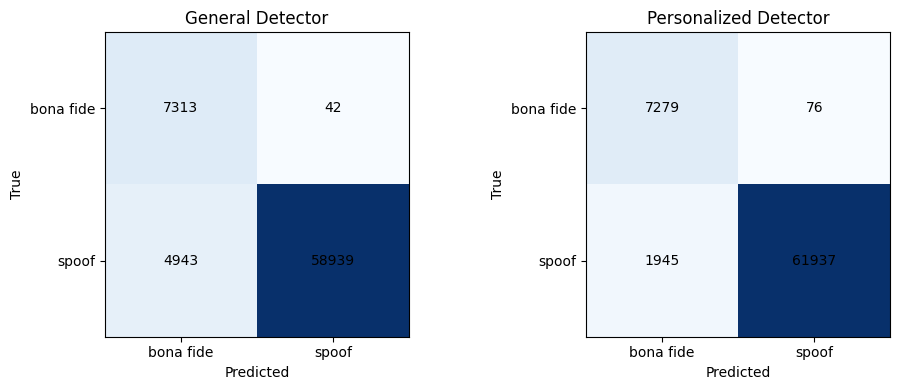


Wrote /kaggle/working/submission.csv


In [15]:
eval_dataset = CachedFeatureDataset(find_pt_dir(os.path.join(BASE, "hybrid_features_eval")))
print(f"Eval samples: {len(eval_dataset)}")

replay_df = run_deployment_replay(eval_dataset, general_model, personalizer)
general_metrics, personalized_metrics, submission = report_results(replay_df)